In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import zscore

plt.style.use("ggplot")

In [5]:
df = pd.read_csv("../data/traffic_cleaned_final.csv")

C:\Users\vikhy\AppData\Local\Temp\ipykernel_7948\4247965084.py:1: DtypeWarning: Columns (0: Ri_MSV30maxRi_Kfz_MobisSo, 1: Ri_MSV30maxRi_Kfz_W, 2: Ri_MSV30maxRi_Kfz_U, 3: Ri_MSV30maxRi_Kfz_S, 4: DL_Q, 5: bSV30_MobisSo_Ri1, 6: bSV30_MobisSo_Ri2, 7: bSV30_W_Ri1, 8: bSV30_W_Ri2, 9: bSV30_U_Ri1, 10: bSV30_U_Ri2, 11: bSV30_S_Ri1, 12: bSV30_S_Ri2, 13: bSV50_MobisSo_Ri1, 14: bSV50_MobisSo_Ri2, 15: bLkwK50_MobisSo_Ri1, 16: bLkwK50_MobisSo_Ri2, 17: Abschnitt_Ast, 18: Station, 19: Ausrichtung) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/traffic_cleaned_final.csv")


In [8]:
ROAD = 6

road = df[df["Str_Nr"] == ROAD].copy()

In [9]:
road = road[
    [
        "Jahr",
        "DZ_Name",
        "Betriebs_km",
        "DTV_Kfz_W_Q",
        "DTV_SV_W_Q",
        "pSV_W_Q",
        "Anz_Fs_Q",
        "Koor_WGS84_N",
        "Koor_WGS84_E",
        "Anmerkungen"
    ]
]

In [10]:
road = road.dropna(
    subset=[
        "Betriebs_km",
        "DTV_Kfz_W_Q",
        "Anz_Fs_Q"
    ]
)

print(road.shape)

(891, 10)


In [ ]:
#sort stations by betriebs_km and year
road = road.sort_values(
    by=[
        "Jahr",
        "Betriebs_km"
    ]
)

In [12]:
road["Traffic_Density"] = (
    road["DTV_Kfz_W_Q"] /
    road["Anz_Fs_Q"]
)

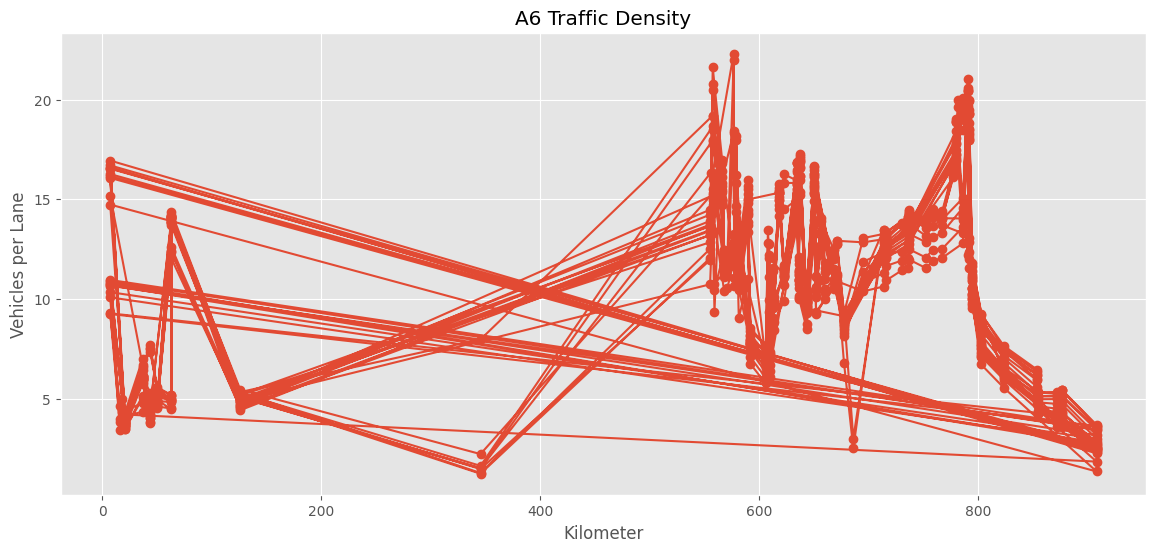

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    road["Betriebs_km"],
    road["Traffic_Density"],
    marker="o"
)

plt.title(f"A{ROAD} Traffic Density")

plt.xlabel("Kilometer")

plt.ylabel("Vehicles per Lane")

plt.grid(True)

plt.show()